In [38]:
import pandas as pd


In [39]:
df=pd.read_csv(r"turboaz.csv")
df

,Sheher,Marka,Model,Buraxilish ili,Ban novu,Reng,Muherrikin hecmi,Muherrikin gucu,Yanacaq novu,Yurush,Suretler qutusu,Oturucu,Yeni,Qiymet,Extra Info,Seller comment
0,Sumqayıt,Mercedes,C 200,1999,Sedan,Qara,2.0 L,175 a.g.,Benzin,366 000 km,Avtomat,Arxa,Xeyr,12500 AZN,Kreditdədir,Barter mümkündür
1,Bakı,Mercedes,C 180,2014,Sedan,Qara,1.6 L,167 a.g.,Benzin,102 000 km,Avtomat,Arxa,Xeyr,31500 $,Barter mümkündür,"Yüngül lehimli disklər,ABS,Yağış sensoru,Mərkə..."
2,Sumqayıt,Mercedes,C 240,2002,Sedan,Qara,2.6 L,177 a.g.,Benzin,469 700 km,Avtomat,Arxa,Xeyr,11700 AZN,Kreditdədir,Barter mümkündür
3,Şirvan,Mercedes,C 180,1998,Sedan,Göy,1.8 L,125 a.g.,Benzin,556 680 km,Avtomat,Arxa,Xeyr,9700 AZN,"Yüngül lehimli disklər,ABS,Mərkəzi qapanma,Kon...",Mawin BAKIDADI. Tecili satilir yaxwi veziyetde...
4,Sumqayıt,Mercedes,C 220,2000,Sedan,Gümüşü,2.2 L,150 a.g.,Dizel,300 000 km,Avtomat,Arxa,Xeyr,12700 AZN,"Yüngül lehimli disklər,ABS,Mərkəzi qapanma,Par...",Vurugu udari deyisen detali curuyu qetiyyen yo...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1323,Bakı,Mercedes,C 180,1996,Sedan,Boz,1.8 L,122 a.g.,Benzin,325 000 km,Avtomat,Arxa,Xeyr,8800 AZN,"Yüngül lehimli disklər,Lyuk",Mawin ozumundu 10ildi mendedi udar gormeyib vu...
1324,Sumqayıt,Mercedes,C 180,1994,Sedan,Bənövşəyi,1.8 L,122 a.g.,Benzin,280 000 km,Avtomat,Arxa,Xeyr,6300 AZN,"Yüngül lehimli disklər,ABS,Lyuk,Yağış sensoru,...",Normal maşindi ...otur sūr..problemi yoxdu..öz...
1325,Bakı,Mercedes,C 230,1998,Sedan,Ağ,2.3 L,150 a.g.,Benzin,272 000 km,Avtomat,Arxa,Xeyr,10900 AZN,"Yüngül lehimli disklər,ABS,Lyuk,Mərkəzi qapanm...",MASHIN TECILI SATILIR!! Mashin tam saz veziyet...
1326,Qusar,Mercedes,C 240,2000,Sedan,Gümüşü,2.4 L,170 a.g.,Benzin,207 000 km,Avtomat,Arxa,Xeyr,11300 AZN,Barter mümkündür,"Yüngül lehimli disklər,ABS,Yağış sensoru,Mərkə..."


DATA CLEANING



In [40]:
df.columns

Index(['Sheher', 'Marka', 'Model', 'Buraxilish ili', 'Ban novu', 'Reng',
       'Muherrikin hecmi', 'Muherrikin gucu', 'Yanacaq novu', 'Yurush',
       'Suretler qutusu', 'Oturucu', 'Yeni', 'Qiymet', 'Extra Info',
       'Seller comment'],
      dtype='object')

In [41]:
df.isnull().any()

Sheher              False
Marka               False
Model               False
Buraxilish ili      False
Ban novu            False
Reng                False
Muherrikin hecmi    False
Muherrikin gucu     False
Yanacaq novu        False
Yurush              False
Suretler qutusu     False
Oturucu             False
Yeni                False
Qiymet              False
Extra Info           True
Seller comment       True
dtype: bool

In [42]:
df.drop(['Extra Info', 'Seller comment'], axis=1, inplace=True) #Istifadə etməyəcəyim üçün bu sütunları silirəm

In [43]:
df.columns= df.columns.str.lower()


In [44]:
df['yurush']=df['yurush'].str.replace('km','').str.replace(' ', '').astype(float)


In [45]:
df['muherrikin hecmi']=df['muherrikin hecmi'].str.replace('L','').str.replace(' ', '').astype(float)

In [46]:
df['muherrikin gucu']=df['muherrikin gucu'].str.replace('a.g.','').str.replace(' ', '').astype(float)

In [47]:
import numpy as np
usd_to_azn = 1.7

qiymet_str = df["qiymet"].astype(str)


amount = qiymet_str.str.extract(r"([\d\.]+)")[0].astype(float)
is_usd = qiymet_str.str.contains("USD", na=False)

df["qiymet"] = np.where(is_usd, amount * usd_to_azn, amount)


In [48]:

print(df.dtypes)


sheher               object
marka                object
model                object
buraxilish ili        int64
ban novu             object
reng                 object
muherrikin hecmi    float64
muherrikin gucu     float64
yanacaq novu         object
yurush              float64
suretler qutusu      object
oturucu              object
yeni                 object
qiymet              float64
dtype: object


In [49]:
df.select_dtypes(include='number').describe()

,buraxilish ili,muherrikin hecmi,muherrikin gucu,yurush,qiymet
count,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000
mean,1999.865964,2.110316,152.990211,279649.921687,13085.617470
std,5.329543,0.351602,30.651318,120619.608010,7424.843573
min,1989.000000,0.200000,90.000000,0.000000,1130.000000
25%,1997.000000,1.800000,125.000000,207750.000000,9700.000000
50%,1999.000000,2.000000,150.000000,278000.000000,11500.000000
75%,2000.000000,2.300000,170.000000,356000.000000,12600.000000
max,2018.000000,6.300000,585.000000,876000.000000,99500.000000


Outlier treatment

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
q3=df['qiymet'].quantile(0.75)
q1=df['qiymet'].quantile(0.25)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
outliers=(df['qiymet']<lower_bound) | (df['qiymet']>upper_bound)

In [52]:
df_without_outliers=df[~(outliers)]

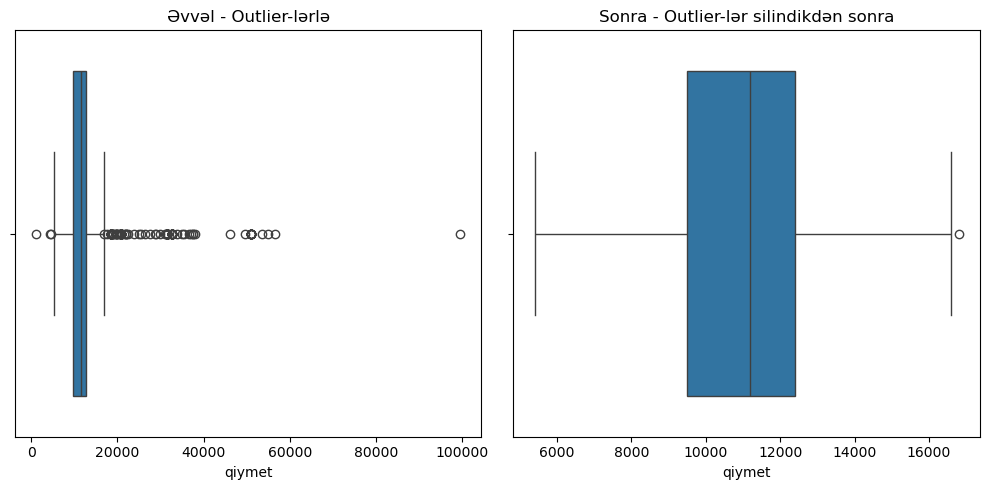

In [53]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['qiymet'])
plt.title('Əvvəl - Outlier-lərlə')

plt.subplot(1,2,2)
sns.boxplot(x=df_without_outliers['qiymet'])
plt.title('Sonra - Outlier-lər silindikdən sonra')

plt.tight_layout()
plt.show()

In [54]:
df=df_without_outliers

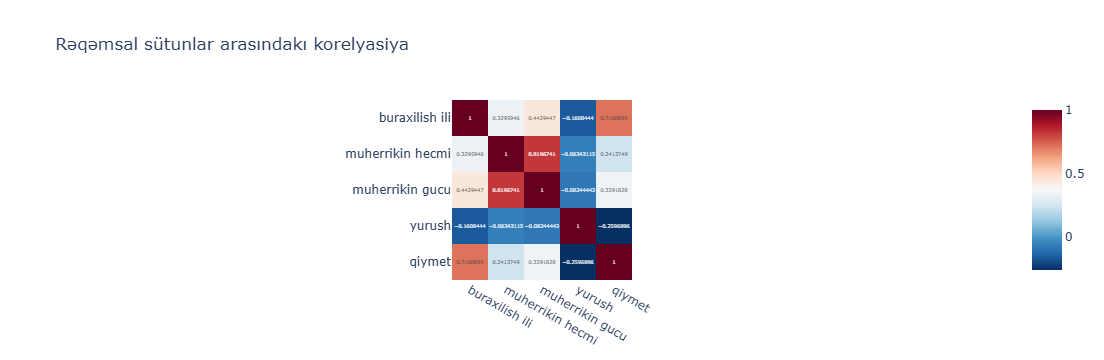

In [55]:
# Yalnız rəqəmsal sütunları seçirik
import plotly.express as px
numeric_df = df.select_dtypes(include='number')

# Korelyasiya matrisi
corr_matrix = numeric_df.corr()
fig = px.imshow(
    corr_matrix,
    text_auto=True,       # hər xanada rəqəmi göstərir
    color_continuous_scale='RdBu_r',  # qırmızı-mavi rəng skalası
    title='Rəqəmsal sütunlar arasındakı korelyasiya'
)

fig.show()


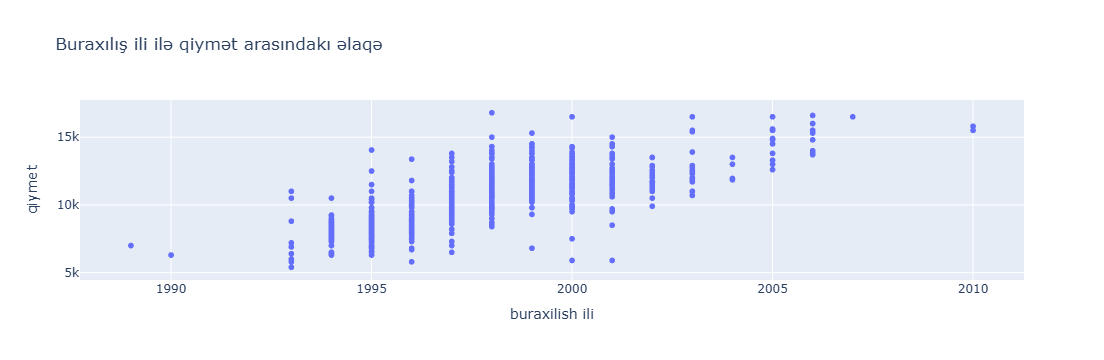

In [56]:
import plotly.express as px

fig = px.scatter(df, x='buraxilish ili', y='qiymet', 
                 title='Buraxılış ili ilə qiymət arasındakı əlaqə')
fig.show()


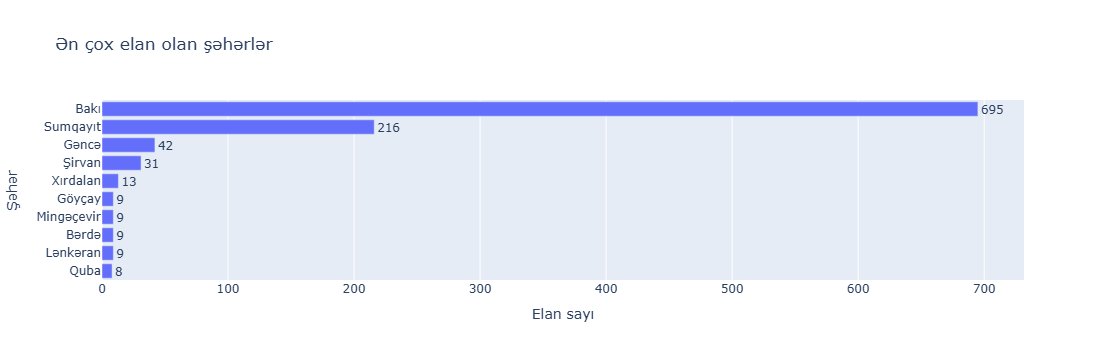

In [57]:
import pandas as pd
import plotly.express as px

# misal üçün df-də 'Şəhər' və 'Elan sayı' sütunları var
# hər şəhərdəki elan sayını hesabla
city_counts = df['sheher'].value_counts().reset_index()
city_counts.columns = ['Şəhər', 'Elan sayı']

# yalnız 10 ən çox elan olan şəhər
top_cities = city_counts.head(10)

# bar chart
fig = px.bar(
    top_cities,
    x='Elan sayı',
    y='Şəhər',
    orientation='h',
    text='Elan sayı',
    title='Ən çox elan olan şəhərlər'
)
fig.update_traces(textposition='outside')
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()





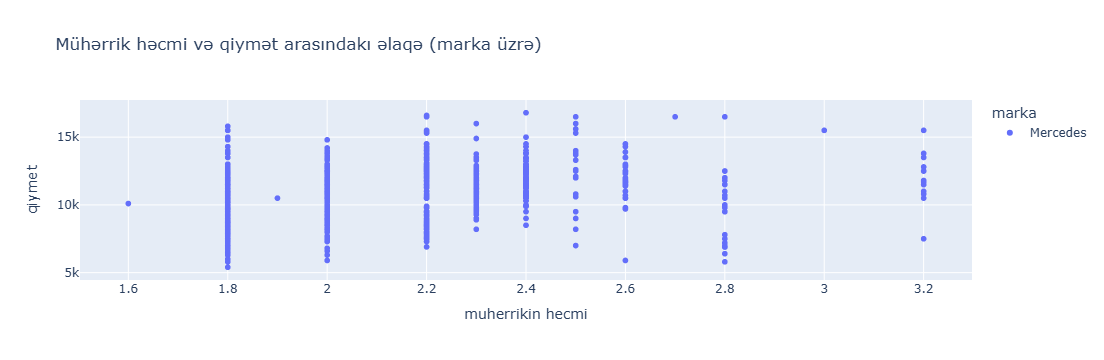

In [58]:
#Mühərrik həcmi artdıqca qiymət necə dəyişir

import plotly.express as px

# Scatter plot: x = mühərrik həcmi, y = qiymət, rəng = marka
fig = px.scatter(
    df,
    x='muherrikin hecmi',
    y='qiymet',
    color='marka',  # fərqli rənglərlə markaları göstərir
    title='Mühərrik həcmi və qiymət arasındakı əlaqə (marka üzrə)',
    hover_data=['model', 'buraxilish ili']  # hover zamanı əlavə məlumat göstərmək üçün
)

fig.show()
#muherrik hecmi 6.3 outlierdir. Adeten 4.5 l e kimi olur

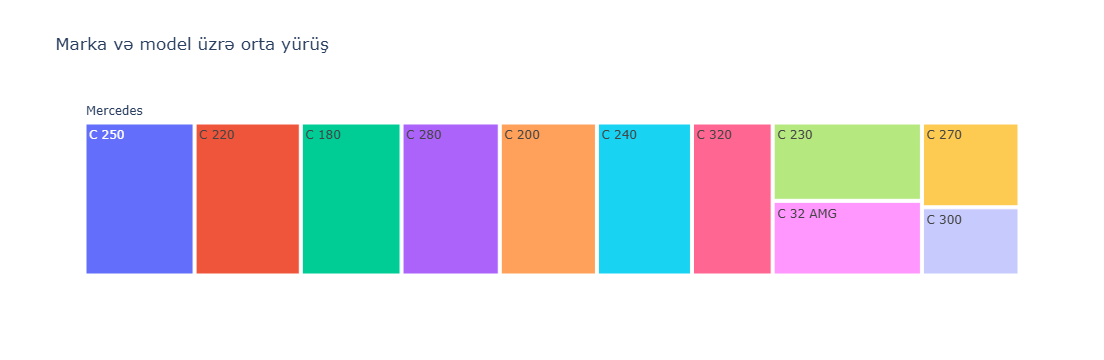

In [64]:
# Marka və model üzrə orta yürüş
avg_mileage = df.groupby(['marka', 'model'])['yurush'].mean().round().reset_index()

# Treemap
fig = px.treemap(
    avg_mileage,
    path=['marka', 'model'],  
    values='yurush',          
    title='Marka və model üzrə orta yürüş'
)

fig.show()


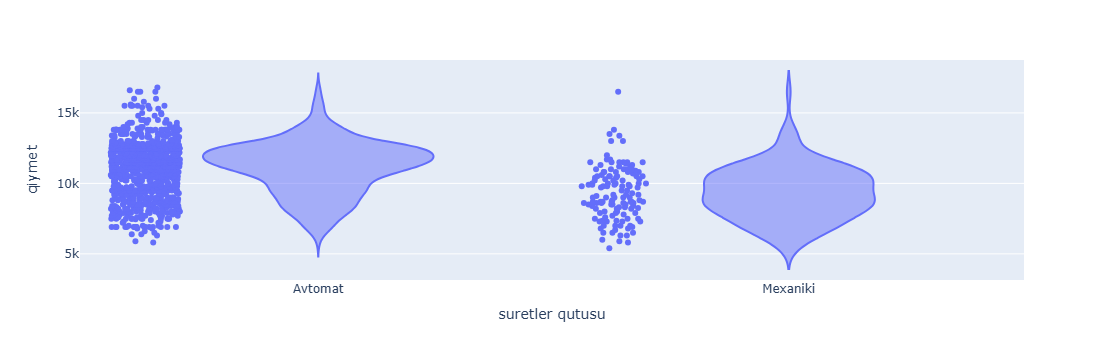

In [65]:
px.violin(df, x='suretler qutusu', y='qiymet', box=False, points='all')
# qiymet ve suretler qutusu

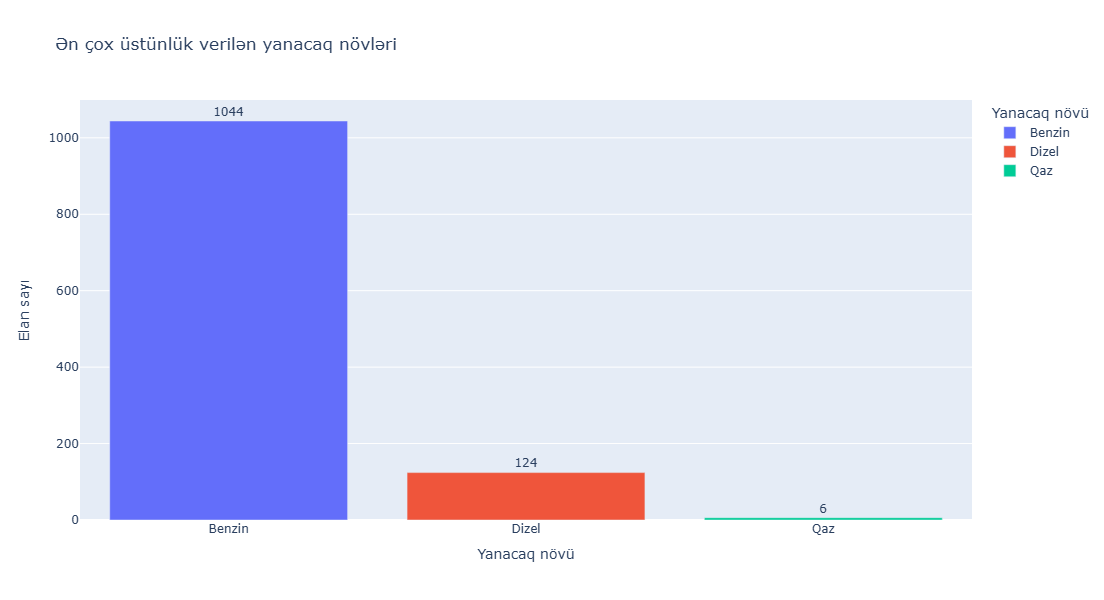

In [66]:
#Hansı yanacaq növü (benzin, dizel, hibrid və s.) daha çox üstünlük təşkil edir?
import plotly.express as px


fuel_counts = df['yanacaq novu'].value_counts().reset_index()
fuel_counts.columns = ['Yanacaq növü', 'Elan sayı']


fig = px.bar(
    fuel_counts,
    x='Yanacaq növü',
    y='Elan sayı',
    text='Elan sayı',
    title='Ən çox üstünlük verilən yanacaq növləri',
    color='Yanacaq növü'
)

fig.update_traces(textposition='outside')
fig.update_layout(
    width=900,   # üfüqi ölçü
    height=600   # şaquli ölçü
)
fig.show()


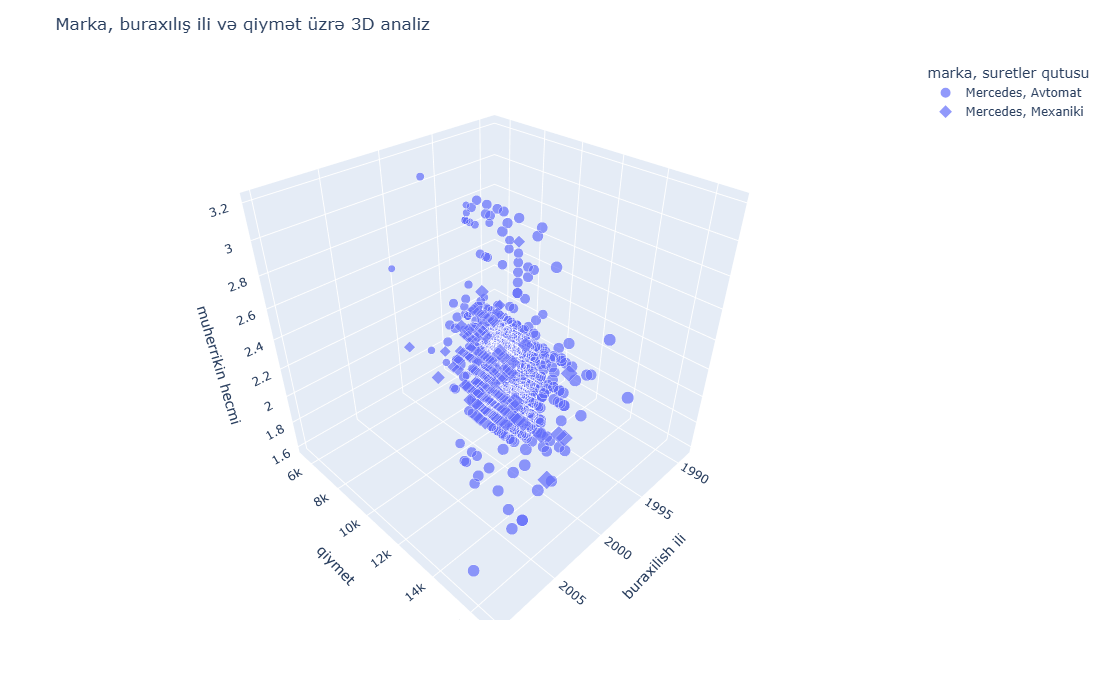

In [67]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='buraxilish ili',
    y='qiymet',
    z='muherrikin hecmi',   
    color='marka',           
    symbol='suretler qutusu', 
    size='qiymet',          
    hover_data=['marka', 'buraxilish ili', 'qiymet']
)

fig.update_layout(
    title='Marka, buraxılış ili və qiymət üzrə 3D analiz',
    width=900,
    height=700
)

fig.show()


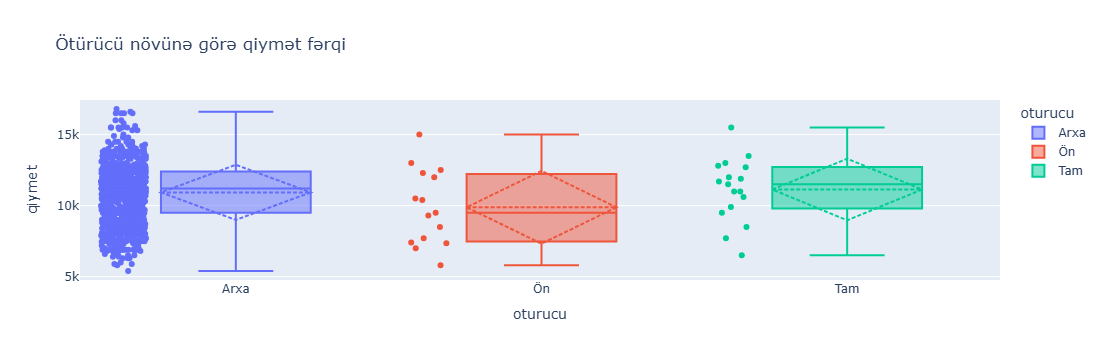

In [68]:
#Ötürücü növü (ön, arxa, tam) qiymətə təsir edirmi?
import plotly.express as px

fig = px.box(
    df,
    x='oturucu',    # ön, arxa, tam
    y='qiymet',
    color='oturucu',
    title='Ötürücü növünə görə qiymət fərqi',
    points='all'    # outlier-ləri göstərir
)

fig.update_traces(boxmean='sd')  # ortalama və standart sapma göstərir
fig.show()


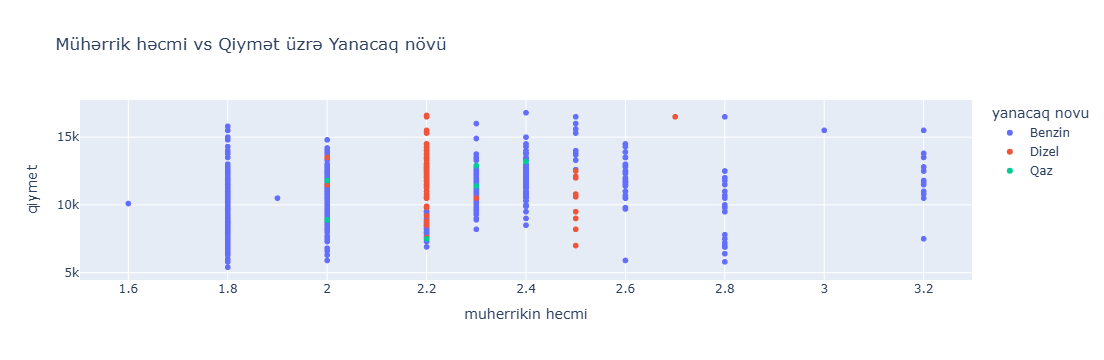

In [69]:
import plotly.express as px

fig = px.scatter(
    df,
    x='muherrikin hecmi',
    y='qiymet',
    color='yanacaq novu',    # yanacaq növü üzrə rəng
    hover_data=['marka', 'model', 'buraxilish ili'],  # əlavə məlumat
    title='Mühərrik həcmi vs Qiymət üzrə Yanacaq növü'
)

fig.show()


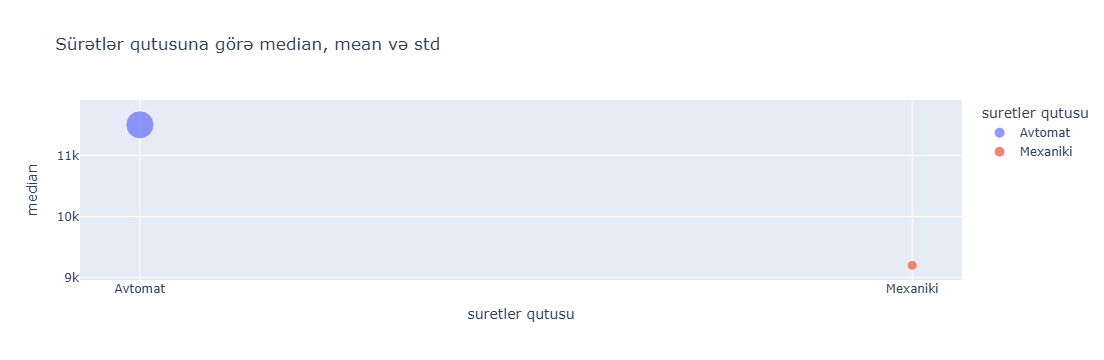

In [70]:
import plotly.express as px
import numpy as np

# Hər sürət qutusu üçün statistikaları hesablamaq
stats_df = df.groupby('suretler qutusu')['qiymet'].agg(
    median='median',
    mean='mean',
    std='std',
    count='count'
).reset_index()


fig = px.scatter(
    stats_df,
    x='suretler qutusu',
    y='median',
    size='count',         
    color='suretler qutusu',
    hover_data=['median','mean','std','count'],
    title='Sürətlər qutusuna görə median, mean və std'
)
fig.show()


In [71]:
df.to_excel("Turbo_yekun.xlsx", index=False)

In [72]:
import os
print(os.getcwd())


C:\Users\Ülviyyə\Desktop
